# Test 2b - Merge, Aggregate, Visualize

## Introduction

This problem tests your ability to merge, aggregate, and visualize data.
You'll work with realistic business data to answer questions about product profitability.

Before submitting, ensure your notebook:

- Includes your verification info (Banner ID and code) as the first cell
- Runs completely with "Kernel → Restart & Run All"
- Shows your work (don't just print final answers)
- Includes your interpretation responses at the end

## Dataset: Bean & Brew Coffee Shop

You've been hired to analyze sales data for Bean & Brew, a local coffee shop chain with three locations. The owner wants to understand which products are most profitable and how profitability varies across locations.

There are two data files:

- `sales.csv` - Individual transaction records
  - `transaction_id`: Unique transaction identifier
  - `timestamp`: Date and time of purchase (format: 'YYYY-MM-DD HH:MM:SS')
  - `location`: Store location ('Downtown', 'Campus', 'Suburb')
  - `product_id`: Product identifier (links to products table)
  - `quantity`: Number of units sold
  - `revenue`: Total revenue from transaction
  - `payment_method`: Payment type ('Cash', 'Credit', 'Mobile')
  - `loyalty_member`: Boolean indicating if customer is loyalty program member
- `products.csv` - Product catalog
  - `product_id`: Unique product identifier
  - `name`: Product name
  - `category`: Product category ('Coffee', 'Tea', 'Pastry', 'Sandwich')
  - `cost`: Cost to make/acquire one unit (for profit calculation)

The dataset contains two weeks of sales data (approximately 3,000 transactions) across 18 products. It includes both regular and premium items in each category.

We are interested in learning which product categories generate the most profit, and how does profitability vary across locations? Complete the following tasks to answer those questions and more.

## Scoring

Total: 30 points (+ 5 bonus)

- Tasks 1-6: 18 points
- Interpretation (Questions 1-4): 12 points
- Bonus: 5 points (optional)

## Generate Your Dataset

Before starting the analysis, you need to generate your unique dataset using your Banner ID.

1. Open a terminal in the folder containing `generate_test2b_data.py`
2. Activate your conda virtual environment
3. Run: `python generate_test2b_data.py`
4. Enter your 9-digit Banner ID when prompted (you'll enter it twice to confirm)

The script will create two files in the `data/` folder:

- `data/products.csv` - Product catalog
- `data/sales.csv` - Transaction records

Important: At the end, the script displays a verification block like this:

```
======================================================================
DATA VERIFICATION INFORMATION
======================================================================
banner id:          904123456
verification code:  5e0dXXXXXXXX
======================================================================
```

Copy the banner id and verification code lines and paste them into the cell below. This is required for submission.

```
paste your banner id and verification code here...

```
```
======================================================================
DATA VERIFICATION INFORMATION
======================================================================
banner id:          904215798
verification code:  5a706fad2942
⚠️  Include those two lines at the top of your notebook submission!
======================================================================
```

## Setup: Load the Data

Run the cell below to load the data. The code is provided for you.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (provided)
sales = pd.read_csv('data/sales.csv', parse_dates=['timestamp'])
products = pd.read_csv('data/products.csv')

print(f"Sales: {len(sales)} transactions")
print(f"Products: {len(products)} items in catalog")
print()
print("Sales preview:")
sales.head()

Sales: 2959 transactions
Products: 18 items in catalog

Sales preview:


,transaction_id,timestamp,location,product_id,quantity,revenue,payment_method,loyalty_member
0,1003,2025-11-13 06:14:00,Campus,103,1.0,4.24,Mobile,False
1,1004,2025-11-13 06:21:00,Downtown,107,1.0,1.91,Credit,True
2,1001,2025-11-13 06:36:00,Campus,113,1.0,3.58,Mobile,True
3,1002,2025-11-13 06:43:00,Downtown,102,1.0,5.10,Credit,False
4,1000,2025-11-13 06:59:00,Downtown,103,1.0,5.28,Credit,False


In [2]:
# Products catalog
products

,product_id,name,category,cost
0,101,Espresso,Coffee,1.2
1,102,Cappuccino,Coffee,1.8
2,103,Latte,Coffee,1.9
3,104,Americano,Coffee,1.0
4,105,Cold Brew,Coffee,1.5
5,106,Nitro Cold Brew,Coffee,2.5
6,107,Green Tea,Tea,0.8
7,108,Chai Latte,Tea,1.2
8,109,Herbal Tea,Tea,0.7
9,110,Premium Matcha,Tea,2.2


## Task 1: Data Quality Check

Investigate the sales data quality and coverage. Your code should answer the following questions:

1. How many missing values are in each column?
2. How many unique product IDs appear in the sales data? Compare this to the catalog size.
3. What is the date range (earliest and latest transaction)?

### Your Code

In [3]:
# Task 1: use isna(), nunique(), min/max on timestamp
missing = sales.isna().sum()
print(f"1. How many missing values are in each column?\n")
for col in missing.index:
    print(f'There are {missing[col]} missing values in the {col} column.')
print(f"\n2. How many unique product IDs appear in the sales data? Compare this to the catalog size.\n")
print(f"There are {sales['product_id'].nunique()} unique product IDs in the sales data.")
print(f"This indicates a potential Data Quality issue as there are only {products['product_id'].nunique()} unique product IDs in the product catalog.")
print(f"\n3. What is the date range (earliest and latest transaction)?\n")
print(f"Sales data was acquired between {sales['timestamp'].min().date()} and {sales['timestamp'].max().date()}.")

1. How many missing values are in each column?

There are 0 missing values in the transaction_id column.
There are 0 missing values in the timestamp column.
There are 0 missing values in the location column.
There are 0 missing values in the product_id column.
There are 3 missing values in the quantity column.
There are 4 missing values in the revenue column.
There are 0 missing values in the payment_method column.
There are 0 missing values in the loyalty_member column.

2. How many unique product IDs appear in the sales data? Compare this to the catalog size.

There are 21 unique product IDs in the sales data.
This indicates a potential Data Quality issue as there are only 18 unique product IDs in the product catalog.

3. What is the date range (earliest and latest transaction)?

Sales data was acquired between 2025-11-13 and 2025-11-26.


## Task 2: Merge Sales with Products

Merge the sales and products DataFrames to add product information (name, category, cost) to each transaction.

### Your Code

In [4]:
# Task 2: use pd.merge() with appropriate join type
merged = pd.merge(sales, products, on='product_id', how='left')
merged.head(n=3)

,transaction_id,timestamp,location,product_id,quantity,revenue,payment_method,loyalty_member,name,category,cost
0,1003,2025-11-13 06:14:00,Campus,103,1.0,4.24,Mobile,False,Latte,Coffee,1.9
1,1004,2025-11-13 06:21:00,Downtown,107,1.0,1.91,Credit,True,Green Tea,Tea,0.8
2,1001,2025-11-13 06:36:00,Campus,113,1.0,3.58,Mobile,True,Scone,Pastry,1.1


The first three (3) rows of the `merged` DataFrame show the `name`, `category` and `cost` columns added to the sales transactiond data. 

## Task 3: Verify the Merge

After merging, verify that the merge worked correctly:

1. Compare the shape of the merged DataFrame to the original sales data
2. Check if any rows have missing values in the product columns (name, category, cost)
3. If there are missing values, identify which product_id(s) are causing the problem

### Your Code

In [5]:
# Task 3: check shape, isna() on product columns, filter to find problem IDs
print(f"1. Compare the shape of the merged DataFrame to the original sales data:\n")
print(f"The shape of the original sales data is: {sales.shape}.")
print(f"The shape of the merged data is: {merged.shape}.")
print(f"\nThis indicats that the three product columns were correctly added to the sales transaction data.") 
print(f"\n2. Check if any rows have missing values in the product columns (name, category, cost):")
missing_merged = merged[['name', 'category', 'cost']].isna().sum()
for col in missing_merged.index:
    print(f'There are {missing_merged[col]} missing values in the {col} column.')
print(f"\n3. If there are missing values, identify which product_id(s) are causing the problem:")
print(f"The following product_id(s) are responsible for the missing data:")
print(f"{merged[merged[['name', 'category', 'cost']].isna().any(axis=1)]['product_id'].unique()}")


1. Compare the shape of the merged DataFrame to the original sales data:

The shape of the original sales data is: (2959, 8).
The shape of the merged data is: (2959, 11).

This indicats that the three product columns were correctly added to the sales transaction data.

2. Check if any rows have missing values in the product columns (name, category, cost):
There are 14 missing values in the name column.
There are 14 missing values in the category column.
There are 14 missing values in the cost column.

3. If there are missing values, identify which product_id(s) are causing the problem:
The following product_id(s) are responsible for the missing data:
[199 201 200]


## Task 4: Profit by Category

First, calculate profit for each transaction: `profit = revenue - (cost × quantity)`

Then summarize profitability by product category. Your code should return a table that shows both total profit and number of transactions for each category. Sort it by total profit (highest first).

### Your Code

In [6]:
# Task 4: create profit column, then groupby with .agg()
merged['profit'] = merged['revenue'] - (merged['cost'] * merged['quantity'])
profit_by_cat=merged.groupby('category').agg(
    total_profit=('profit', 'sum'),
    total_transactions=('transaction_id', 'count')
).sort_values('total_profit', ascending=False)
profit_by_cat

,total_profit,total_transactions
category,,
Sandwich,4649.70,654
Coffee,2617.08,1063
Pastry,1651.15,570
Tea,952.71,658


## Task 5: Profit by Category and Location

Analyze how profitability varies by both category and location. Your code should produce a table that shows the following for every combination of category and location:

- Total profit
- Average profit per transaction
- Number of transactions

Display the results as a flat table (i.e., without a nested/hierarchical index).

### Your Code

In [7]:
# Task 5: groupby multiple columns, .agg() with dict, reset_index()
merged.groupby(['category', 'location']).agg(
    total_profit=('profit', 'sum'),
    avg_profit_per_transaction=('profit', 'mean'),
    total_transactions=('transaction_id', 'count')
).round(2).reset_index()

,category,location,total_profit,avg_profit_per_transaction,total_transactions
0,Coffee,Campus,1260.73,2.10,602
1,Coffee,Downtown,1117.98,3.01,372
2,Coffee,Suburb,238.37,2.68,89
3,Pastry,Campus,645.68,2.51,257
4,Pastry,Downtown,633.18,3.54,180
5,Pastry,Suburb,372.29,2.82,133
6,Sandwich,Campus,883.10,5.66,156
7,Sandwich,Downtown,2711.91,8.24,331
8,Sandwich,Suburb,1054.69,6.35,167
9,Tea,Campus,211.58,1.10,193


## Task 6: Visualize Category Profitability

Create a bar chart showing total profit by product category. Use seaborn and ensure that the result:

- Has clearly labeled categories
- Includes a descriptive title
- Makes it clear which category is most/least profitable

### Your Code

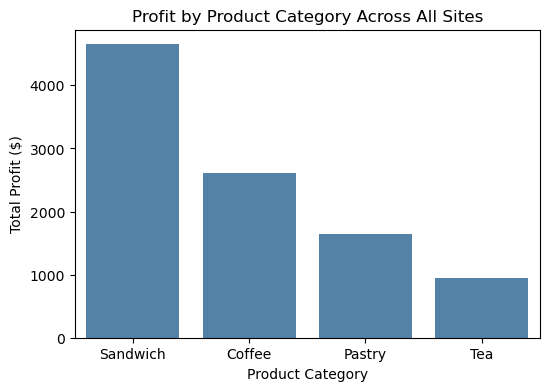

In [8]:
# Task 6: use sns.barplot() with aggregated data
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=profit_by_cat, x='category', y='total_profit', color='steelblue')
ax.set_title('Profit by Product Category Across All Sites')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Profit ($)')
plt.show()

## Interpretation

Concisely answer the following questions based on your analysis.


1. What might go wrong if you did not verify the merge in Task 3 before proceeding with the analysis?
2. In Tasks 4 and 5, you aggregated data at different levels of detail (by category, then by category and location). How did this change what you could learn from the data?
3. Reflect on the patterns you discovered in your analysis. What valuable insights did your work generate?
4. The coffee shop owner asks: "Based on your analysis, what's the single most important thing I should do to improve profitability?" Provide a specific, actionable recommendation. Justify your recommendation with evidence from your analysis (include specific numbers from your results). Also, suggest additional analysis that you feel might be worthwhile.

### Your Answers

*Interpretation responses here*
1. If you did not verify the merge in Task 3 before proceeding with the analysis, the wrong merge type (`on = ''`) could have been used, resulting in insufficient data. This potential mistake is what I was most concerned about. I took some time to really think about the desired outcome: we wanted to add the product information to each sales transaction, i.e., keep everything from the sales dataframe and if the `product_id` exists, add information from the products catalog. An `inner` or `right` join would have eliminated the data in the sales dataframe for which there was no valid `product_id`. It does also appear that an `outer` join would have provided the requested information. Confirming the shape of the original sales dataframe matches that of the newly merged datafram verifies that all desired information was maintained.
2. Task 4 helped us better understand what product categories are the most profitable. Task 5 further expanded the anlaysis by investigating how much profit each product category earns at each location. This information is more powerful because it can allow for more site specific decisions to be made compared to general product category decisions cross the board: i.e., maybe the `$211.58` total profit of Tea is unsustainable at the Campus location, indicating that either a) Tea needs to be removed from the Campus menu, or b) the price of Tea needs to be raised to increase the profit margin.
3. Overall profit margin is quite useful, because it can really facilitate informed business and financial decisions. Sandwiches by far provide the most profit margin, while Tea provides the least. Coffee leads the total sales by over 400 transactions across all sites, indicating it is the most popular menu item. It is particularly popular at the Campus location, potentially indicating that caffeine dependent students are frequent customers. Tea is the least profitable despite being the second most popular item on the menu across sites. With such significant time invested serving Tea, it should be investigated if the profit margin is sufficient or if action should be taken to increase it. Additionally, I think the missing data is the most insightful, as it indicates a significant data quality issue in the source data. Either the products catalog is outdated and needs to be updated with the latest menu items, or there should be more controls over the sales data so that only items that exists in the products catalog can be input into sales transactions (data validation in excel).
4. Personally, I think the single most important thing to improve profitabiltiy is to increase the average profit margin per transaction for Tea sales. Tea is the second most popular item on the menu (658 overall transactions) but the least profitiable by far (`$952.71` in total profit, almost `$700` less than the next product category). This is most likely due to its small profit margin across sites (`$1.10` at the Campus location, `$1.65` Downtown and `$1.55` in the Suburbs). There are two ways to increase profit margin, decrease costs or increase price. This is obviously a very touchy subject because there is only so much a business can do to lower costs, and raising prices comes at the risk of losing sales. I think customer demographic should greatly influence this decision. The Downtown location is most likely serving working class professionals with a stable income whereas the Campus location might be serving more "penny-pinching" college students who might respond much less favorably if prices increase. So, I would start by raising the price of Tea at the Downtown location and observe the impact on total sales, and make decisions about the Subrb and Campus locations based on the results. Additional analysis I feel might be worthwhile is sales transactions per hour/time period. Adding a column for profitibilty by hour could help indicate busy vs. slow hours where more vs. less help is needed. This could be particualarly helpful during brekfast and lunch hours, as sales might be lost to students or professionals who in a rush to make it to school or work on time.

## Bonus: Time-Based Analysis (Optional)

For extra credit, investigate a time-based question of your choosing. Examples of questions you could explore include:

- Do sales patterns differ between weekdays and weekends?
- Which hours are busiest at each location?
- Is there a day of the week that stands out for profitability?

For full credit you must:

- State your question clearly
- Show your analysis code
- Summarize what you found in 2-3 sentences

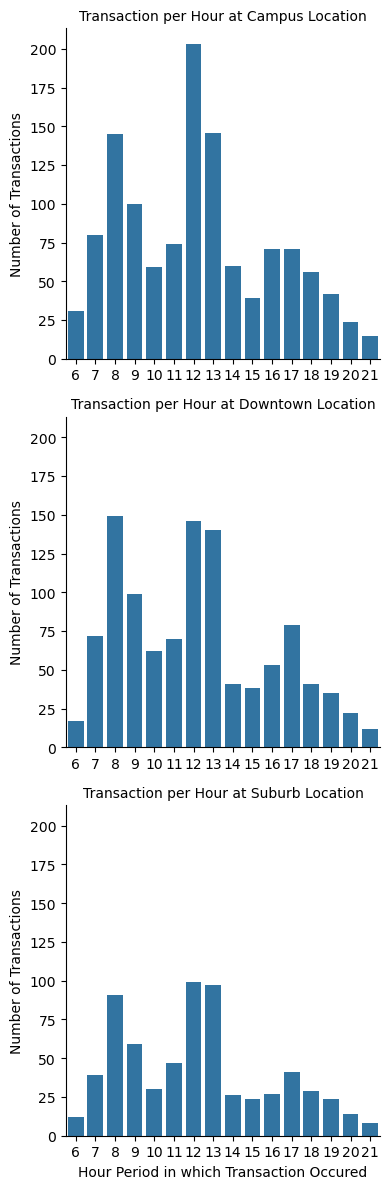

In [9]:
# Bonus: Your time-based analysis here
# Which hours are busiest at each location?
# sales.iloc[0]['timestamp'].hour
sales['hour_of_sale'] = sales['timestamp'].dt.hour
sales_hour = sales.groupby('location')['hour_of_sale'].value_counts().reset_index(name='count')
g = sns.FacetGrid(data=sales_hour, col='location', col_wrap=1, height=4, sharex=False)
g.map_dataframe(sns.barplot, x='hour_of_sale', y='count')
g.set_titles('Transaction per Hour at {col_name} Location')
g.set_xlabels('Hour Period in which Transaction Occured')
g.set_ylabels('Number of Transactions')
#fig, ax = plt.subplots(figsize=(6,4))
#sns.barplot(data=sales_hour, x='hour_of_sale', y='count', color='steelblue')
#ax.set_title('Transactions per Hour Period')
#ax.set_xlabel('Hour Period in which Transaction Occured')
#ax.set_ylabel('Number of Transactions')
#plt.show()

### Your Findings

*Bonus findings here (state your question and what you discovered)*
For the Bonus, I created a Facet Grid of bar charts to investigate **what hour periods are the busiest at each location**. First and foremost, the Campus location gets the bussiest during rush hours, followed by the Downtown location, and then the Suburb location. Each location has a very similar "trimodal" shape, with 8 am being the busiest hour in the morning, 12 pm being the busiest hour in the afternoon, and 5 pm being the busiest hour in the evening. Each location experiences a build-up to each segment of the day's rush hour and then a fall-down and lull period following the rush. This information can be used to determine staffing needs at each location based on time period. 

## Submission

Ensure your notebook:

- Has the verification block (Banner ID and code) as the first cell
- Runs completely from top to bottom without errors
- Shows all task outputs clearly
- Includes all interpretation responses
- Is saved and committed to your repository

Follow the submission instructions on Canvas to submit your work.